# TSDA 
 Translational Spring-Damper-Actuator

 - 공식문서: https://api.projectchrono.org/classchrono_1_1_ch_link_t_s_d_a.html

 ChLinkTSDA는 두 rigid body 사이의 거리 변화에 따라 힘을 생성하는 1차원 force element로, 선형 스프링-댐퍼 모델 또는 사용자 정의 force 함수를 통해 동적 상호작용을 구현한다. 해당 force는 시스템의 운동 방정식에 포함되어 solver에 의해 통합적으로 계산된다.

 - 즉, “두 body 사이 거리 기반 force를 생성하고, 이를 시스템 dynamics에 포함시키는 요소”

## Intro
PyChrono는 C++ 기반의 Chrono 물리 엔진을 Python에서 사용할 수 있도록 하는 wrapper로, 내부적으로는 C++에서 정의된 클래스와 함수가 그대로 호출된다.
- Chrono = C++ 물리엔진
- PyChrono = Python 인터페이스

https://api.projectchrono.org/pychrono_reference.html

1) 구조
- Python → wrapper → C++ solver

2) 스프링 시스템의 위치
- ChLinkTSDA → Force element (external force)
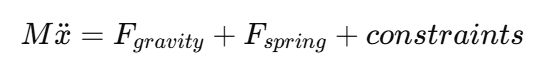
- External force: gravity / spring / actuator

3) 실행 흐름
- Force 계산 → solver → 상태 업데이트

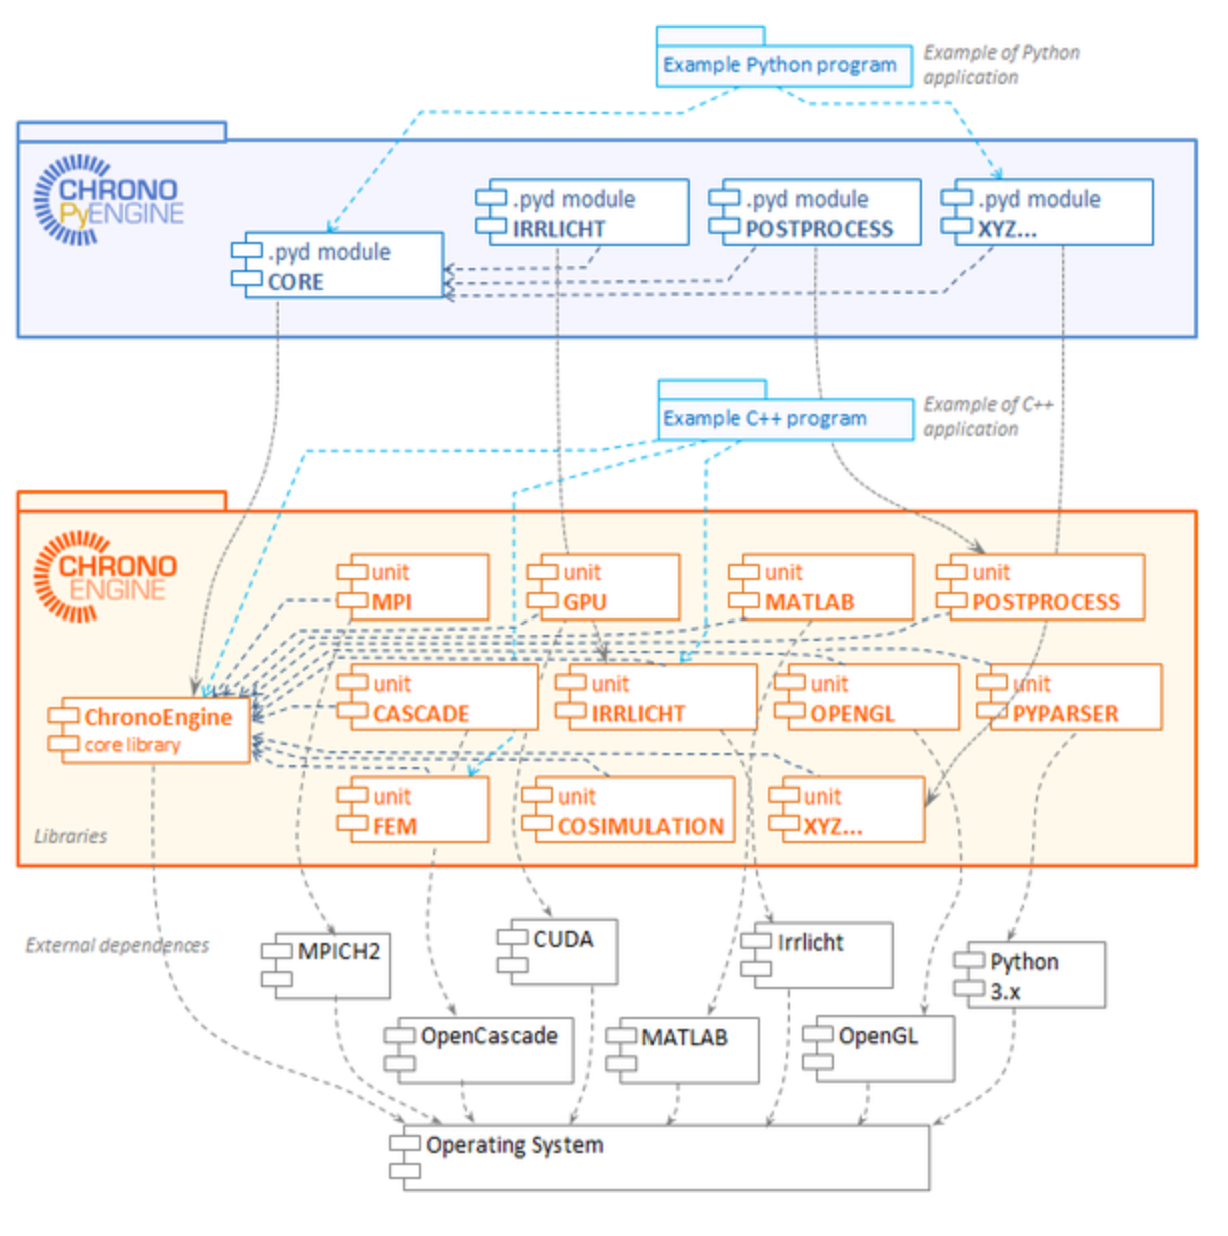

### 1. 정의
- 두 개의 rigid body 사이에 작용하는 1차원 force element

### 2. 물리적 의미
- Spring (탄성력)
- Damper (감쇠력)
- Actuator (외력)

### 3. 기본 force 모델
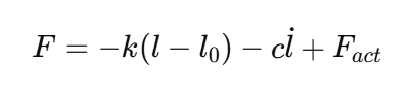
- l: 현재 길이
- l_0: 자연 길이 (rest length)
- k: 스프링 상수
- c: 감쇠 계수
- l': 길이 변화 속도
- F_act: 외부 actuator 힘

### 4. 작동 방식 (내부흐름)
1) 두 body의 attachment point 정의
2) 현재 거리 l 계산
3) 상대 속도 l' 계산
4) force 계산
5) 해당 force를 두 body에 반대 방향으로 적용

### 5. 특징
- 1d force element - 두 점을 연결하는 선의 방향
- 에너지 저장 가능 - spring → potential energy 
- damping 포함 - 에너지 소산
- actuator 포함 가능 - 외력 입력 가능


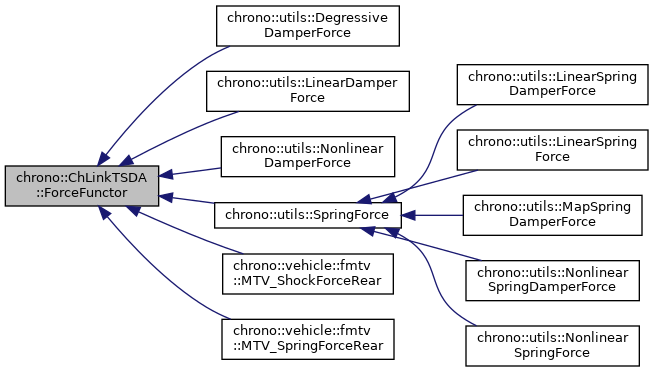

### 6. Force 계산 방식 2가지
1) 기본 선형 모델

In [ ]:
SetSpringCoefficient(k)
SetDampingCoefficient(c)
SetRestLength(l0)

2) 사용자 정의 force

In [ ]:
SetForceFunctor(...)

### 7. ForceFunctor ***
사용자가 직접 force 정의가능:
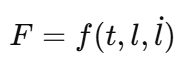

- 즉, nonlinear spring, 외력 포함, 시간 의존성 가능함 -> RL확장시 중요

### 9. 수학적 위치 ***
TSDA force는 Chrono 시스템에서:
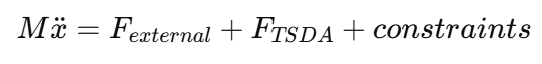
- 여기서 TSDA는 external force 항에 포함됨

### 10. Solver와의 관계
- TSDA force → system force vector에 추가
- 이후 solver가 전체 dynamics 해결

## Tutorial: demo_MBS_spring.py

### 원본 깃허브 코드

In [1]:
# =============================================================================
# PROJECT CHRONO - http://projectchrono.org
#
# Copyright (c) 2014 projectchrono.org
# All rights reserved.
#
# Use of this source code is governed by a BSD-style license that can be found
# in the LICENSE file at the top level of the distribution and at
# http://projectchrono.org/license-chrono.txt.
#
# =============================================================================
# Authors: Simone Benatti
# =============================================================================
#
# Simple example demonstrating the use of ChLinkTSDA.
#
# Two bodies, connected with identical (but modeled differently) spring-dampers
# are created side by side.
#
# Recall that Irrlicht uses a left-hand frame, so everything is rendered with
# left and right flipped.
#
# =============================================================================

import pychrono as chrono
import pychrono.irrlicht as chronoirr

# =============================================================================

rest_length = 1.5
spring_coef = 50
damping_coef = 1

# =============================================================================

# Functor class implementing the force for a ChLinkTSDA link.
# In this simple demonstration, we just reimplement the default linear spring-damper.
class MySpringForce(chrono.ForceFunctor):
    def __init__(self):
        super(MySpringForce, self).__init__()
    
    def evaluate(self,         #
                 time,         # current time
                 rest_length,  # undeformed length
                 length,       # current length
                 vel,          # current velocity (positive when extending)
                 link):        # associated link
        force = -spring_coef * (length - rest_length) - damping_coef * vel
        return force

# =============================================================================

print("Copyright (c) 2017 projectchrono.org")

sys = chrono.ChSystemNSC()
sys.SetGravitationalAcceleration(chrono.ChVector3d(0, 0, 0))

# Create the ground body with two visualization spheres
# -----------------------------------------------------

ground = chrono.ChBody()
sys.AddBody(ground)
ground.SetFixed(True)
ground.EnableCollision(False)

sph_1 = chrono.ChVisualShapeSphere(0.1)
ground.AddVisualShape(sph_1, chrono.ChFramed(chrono.ChVector3d(-1, 0, 0)))

sph_2 = chrono.ChVisualShapeSphere(0.1)
ground.AddVisualShape(sph_2, chrono.ChFramed(chrono.ChVector3d(1, 0, 0)))

# Create a body suspended through a ChLinkTSDA (default linear)
# -------------------------------------------------------------

body_1 = chrono.ChBody()
sys.AddBody(body_1)
body_1.SetPos(chrono.ChVector3d(-1, -3, 0))
body_1.SetFixed(False)
body_1.EnableCollision(False)
body_1.SetMass(1)
body_1.SetInertiaXX(chrono.ChVector3d(1, 1, 1))

# Attach a visualization asset.
box_1 = chrono.ChVisualShapeBox(1, 1, 1)
box_1.SetColor(chrono.ChColor(0.6, 0, 0))
body_1.AddVisualShape(box_1)

# Create the spring between body_1 and ground. The spring end points are
# specified in the body relative frames.
spring_1 = chrono.ChLinkTSDA()
spring_1.Initialize(body_1, ground, True, chrono.ChVector3d(0, 0, 0), chrono.ChVector3d(-1, 0, 0))
spring_1.SetRestLength(rest_length)
spring_1.SetSpringCoefficient(spring_coef)
spring_1.SetDampingCoefficient(damping_coef)
sys.AddLink(spring_1)

# Attach a visualization asset.
spring_1.AddVisualShape(chrono.ChVisualShapeSpring(0.05, 80, 15))

# Create a body suspended through a ChLinkTSDA (custom force functor)
# -------------------------------------------------------------------

body_2 = chrono.ChBody()
sys.AddBody(body_2)
body_2.SetPos(chrono.ChVector3d(1, -3, 0))
body_2.SetFixed(False)
body_2.EnableCollision(False)
body_2.SetMass(1)
body_2.SetInertiaXX(chrono.ChVector3d(1, 1, 1))

# Attach a visualization asset.
box_2 = chrono.ChVisualShapeBox(1, 1, 1)
box_2.SetColor(chrono.ChColor(0, 0, 0.6))
body_2.AddVisualShape(box_2)

# Create the spring between body_2 and ground. The spring end points are
# specified in the body relative frames.
force = MySpringForce()

spring_2 = chrono.ChLinkTSDA()
spring_2.Initialize(body_2, ground, True, chrono.ChVector3d(0, 0, 0), chrono.ChVector3d(1, 0, 0))
spring_2.SetRestLength(rest_length)
spring_2.RegisterForceFunctor(force)
sys.AddLink(spring_2)

# Attach a visualization asset.
spring_2.AddVisualShape(chrono.ChVisualShapeSpring(0.05, 80, 15))

# Create the Irrlicht application
# -------------------------------

vis = chronoirr.ChVisualSystemIrrlicht()
vis.AttachSystem(sys)
vis.SetWindowSize(1024,768)
vis.SetWindowTitle('ChLinkTSDA demo')
vis.Initialize()
vis.AddLogo(chrono.GetChronoDataFile('logo_chrono_alpha.png'))
vis.AddSkyBox()
vis.AddCamera(chrono.ChVector3d(0, 0, 6))
vis.AddTypicalLights()

# Simulation loop
frame = 0

while vis.Run() :
    vis.BeginScene() 
    vis.Render()
    vis.EndScene()
    sys.DoStepDynamics(1e-3)

    if (frame % 50 == 0) :
        print( '{:.6}'.format(str(sys.GetChTime())) + " \n" + '{:.6}'.format(str(spring_1.GetLength())) + 
                 "  " + '{:.6}'.format(str(spring_1.GetVelocity())) + "  "
                 + '{:.6}'.format(str(spring_1.GetForce())))

        print('{:.6}'.format(str(spring_2.GetLength())) + "  " +
                  '{:.6}'.format(str(spring_2.GetVelocity())) + "  " + '{:.6}'.format(str(spring_2.GetForce())) )
    

    frame += 1


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\lahee\anaconda3\envs\chrono\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\lahee\anaconda3\envs\chrono\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\lahee\anaconda3\envs\chrono\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_loop.start()
  File "c:

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Copyright (c) 2017 projectchrono.org
0.001 
2.9999  -0.075  -74.92
2.9999  -0.075  -74.92
0.0510 
2.9032  -3.650  -66.51
2.9032  -3.650  -66.51
0.1010 
2.6419  -6.610  -50.48
2.6419  -6.610  -50.48
0.1510 
2.2554  -8.628  -29.14
2.2554  -8.628  -29.14
0.2010 
1.7966  -9.506  -5.326
1.7966  -9.506  -5.326
0.2510 
1.3244  -9.193  17.971
1.3244  -9.193  17.971
0.3010 
0.8964  -7.786  37.963
0.8964  -7.786  37.963
0.3510 
0.5622  -5.507  52.396
0.5622  -5.507  52.396
0.4010 
0.3574  -2.675  59.800
0.3574  -2.675  59.800
0.4510 
0.3006  0.3417  59.624
0.3006  0.3417  59.624
0.5010 
0.3914  3.1704  52.258
0.3914  3.1704  52.258
0.5510 
0.6115  5.4783  38.943
0.6115  5.4783  38.943
0.6010 
0.9282  7.0123  21.576
0.9282  7.0123  21.576
0.6510 
1.2984  7.6249  2.4525
1.2984  7.6249  2.4525
0.7010 
1.6749  7.2871  -16.03
1.6749  7.2871  -16.03
0.7510 
2.0119  6.0861  -31.68
2.0119  6.0861  -31.68
0.8010 
2.2707  4.2089  -42.74
2.2707  4.2089  -42.74
0.8510 
2.4237  1.9153  -48.10
2.4237  1.9153 

### 코드 분석

In [4]:
import pychrono as chrono
import pychrono.irrlicht as chronoirr

### 1. 파라미터 정의
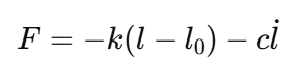

스프링 모델의 핵심 상수

- `rest_length` = 1.5
    자연길이. 스프링이 힘을 전혀 내지 않는 기준 길이
- `spring_coef` = 50
    스프링 상수 𝑘
- `damping_coef` = 1
    감쇠계수 𝑐


In [5]:
rest_length = 1.5   # 스프링 자연길이 (힘이 0인 길이)
spring_coef = 50    # 스프링 강성 k
damping_coef = 1    # 감쇠 계수 c

### 2. MySpringForce 클래스 ***(중요)
Chrono의 ForceFunctor를 상속해서, 스프링 힘을 사용자가 직접 계산하게 만든다.

`evaluate(...)` 인자 의미
- `time`: 현재 시각
- `rest_length`: 자연길이
- `length`: 현재 스프링 길이
- `vel`: 스프링 길이의 시간 변화율
    - 양수면 늘어나는 중
    - 음수면 줄어드는 중
- `link`: 연결된 `ChLinkTSDA` 객체

계산하는 힘

`force = -spring_coef * (length - rest_length) - damping_coef * vel`


-> 완전한 선형 spring-damper 모델

- 길이가 자연길이보다 길면 (length - rest_length)>0 이고, 마이너스가 붙어서 원래 길이로 돌아가려는 힘이 생김
- vel > 0이면 늘어나는 중이므로, 감쇠력은 그 움직임을 방해하는 방향으로 작용

즉 이 코드는 “기본 TSDA의 내장 선형식”을 똑같이 다시 구현한 것

-> 두 스프링 결과가 같아야 정상

In [6]:
# 기본 TSDA랑 똑같은 식을 직접 구현
class MySpringForce(chrono.ForceFunctor):

    def __init__(self):
        super(MySpringForce, self).__init__()

    # 매 timestep마다 호출됨 → 여기서 힘 계산
    def evaluate(self, time, rest_length, length, vel, link):

        # Hooke + damping
        force = -spring_coef * (length - rest_length) - damping_coef * vel

        return force

### 3. 시스템 생성
`ChSystemNSC()`

Chrono 물리계 전체를 만든다.

여기에 body, link, force 등을 다 넣고 solver가 전체 동역학을 푼다.

In [9]:
sys = chrono.ChSystemNSC()

# 중력 제거 (순수 스프링만 보기 위해)
sys.SetGravitationalAcceleration(chrono.ChVector3d(0, 0, 0))

### 4. Ground 생성
이 ground는 바닥이라기보다 고정된 기준 물체

- `SetFixed(True)`: 절대 움직이지 않음
- `EnableCollision(False)`: 충돌 계산 안 함

In [10]:
ground = chrono.ChBody()
sys.AddBody(ground)

ground.SetFixed(True)           # 절대 안 움직임
ground.EnableCollision(False)   # 충돌 계산 안함

#### 시각화
 - 왼쪽 고정점: (−1,0,0)
 - 오른쪽 고정점: (1,0,0)

즉 왼쪽 스프링과 오른쪽 스프링의 고정 위치를 눈으로 볼 수 있게 해둔 것

In [12]:
# 왼쪽 고정점 (시각화용)
sph_1 = chrono.ChVisualShapeSphere(0.1)
ground.AddVisualShape(sph_1, chrono.ChFramed(chrono.ChVector3d(-1, 0, 0)))

# 오른쪽 고정점 (시각화용)
sph_2 = chrono.ChVisualShapeSphere(0.1)
ground.AddVisualShape(sph_2, chrono.ChFramed(chrono.ChVector3d(1, 0, 0)))

### 5. 첫 번쨰 질량체 `body_1`
왼쪽에 놓인 움직이는 물체다.

- 초기 위치: (-1, -3, 0)
- 질량: 1
- 관성모멘트: (1,1,1)

즉, 고정점 (−1,0,0)의 아래쪽 (−1,−3,0)에 매달려 있는 박스

초기 스프링 길이는 대략 3이고, 자연길이는 1.5니까 처음부터 스프링이 늘어나 있음 

-> 시작하자마자 위쪽으로 잡아당기는 힘이 생김

In [16]:
body_1 = chrono.ChBody()
sys.AddBody(body_1)

body_1.SetPos(chrono.ChVector3d(-1, -3, 0))  # 아래쪽 위치
body_1.SetFixed(False)                       # 움직일 수 있음
body_1.EnableCollision(False)
body_1.SetMass(1)                            # 질량
body_1.SetInertiaXX(chrono.ChVector3d(1,1,1))

In [17]:
# 시각화용 박스
box_1 = chrono.ChVisualShapeBox(1,1,1)
box_1.SetColor(chrono.ChColor(0.6, 0, 0))
body_1.AddVisualShape(box_1)

### 6. 첫 번쨰 스프링 `spring_1` - 기본 내장 선형 모델

기본 TSDA 사용법

`Initialize(...)`

1) 두 물체 사이를 연결

- body_1: 움직이는 질량체
- ground: 고정점이 있는 물체
- True: 여기서는 점 좌표를 절대좌표계 기준으로 해석
- chrono.ChVector3d(0,0,0): 첫 번째 연결점
- chrono.ChVector3d(-1,0,0): 두 번째 연결점

실질적으로는 body_1의 중심과 ground의 왼쪽 고정점 (−1,0,0)을 연결

2) 이후 설정

- `SetRestLength(rest_length)`: 자연길이 1.5
- `SetSpringCoefficient(spring_coef)`: 스프링 상수 50
- `SetDampingCoefficient(damping_coef)`: 감쇠 1

즉 `spring_1`은 Chrono에 내장된 선형 spring-damper

In [19]:
spring_1 = chrono.ChLinkTSDA()

# body_1 ↔ ground 연결
spring_1.Initialize(
    body_1,
    ground,
    True,
    chrono.ChVector3d(0,0,0),   # body_1 기준 연결점
    chrono.ChVector3d(-1,0,0)   # ground 기준 연결점
)


In [20]:
# 스프링 설정 (기본 모델 사용)
spring_1.SetRestLength(rest_length)
spring_1.SetSpringCoefficient(spring_coef)
spring_1.SetDampingCoefficient(damping_coef)

sys.AddLink(spring_1)

In [21]:
# 스프링 모양 그리기
spring_1.AddVisualShape(chrono.ChVisualShapeSpring(0.05, 80, 15))

### 7. 두 번째 질량체 `body_2` 
오른쪽에 놓인 동일한 질량체로, 
왼쪽과 완전히 대칭 구조다.

- 위치만 x=1
- 나머지 질량, 관성 등은 동일

즉 공정한 비교를 위해 두 시스템을 최대한 같게 만든 것

In [24]:
body_2 = chrono.ChBody()
sys.AddBody(body_2)

body_2.SetPos(chrono.ChVector3d(1, -3, 0))  # 오른쪽
body_2.SetFixed(False)
body_2.EnableCollision(False)
body_2.SetMass(1)
body_2.SetInertiaXX(chrono.ChVector3d(1,1,1))

In [25]:
# 시각화용 박스
box_2 = chrono.ChVisualShapeBox(1,1,1)
box_2.SetColor(chrono.ChColor(0, 0, 0.6))
body_2.AddVisualShape(box_2)

### 8. 두 번쨰 스프링 `spring_2` - 사용자 정의 힘 모델
`SetSpringCoefficient`, `SetDampingCoefficient`를 쓰지 않는다.

대신 `spring_2.RegisterForceFunctor(force)`를 통해 `MySpringForce()` 객체를 등록

즉 `spring_2`의 힘은 내장 선형식을 쓰는 게 아니라,
매 스텝마다 `MySpringForce.evaluate(...)`를 호출해서 직접 계산함

-> 그런데 `evaluate` 안에 넣은 식이 `spring_1`과 완전히 같으므로,
이론적으로 `spring_1`과 `spring_2`는 같은 운동을 해야 한다


In [26]:
force = MySpringForce()   # 우리가 만든 힘 함수

spring_2 = chrono.ChLinkTSDA()

spring_2.Initialize(
    body_2,
    ground,
    True,
    chrono.ChVector3d(0,0,0),
    chrono.ChVector3d(1,0,0)
)

spring_2.SetRestLength(rest_length)

# 기본 모델 대신 우리가 만든 힘 사용
spring_2.RegisterForceFunctor(force)

sys.AddLink(spring_2)

spring_2.AddVisualShape(chrono.ChVisualShapeSpring(0.05, 80, 15))

### 9. 시각화

이 부분은 물리 계산 자체보다는 화면 출력용임

- Chrono 시스템을 Irrlicht에 연결
- 창 크기 설정
- 카메라 설정
- 하늘, 조명, 로고 추가

-> 즉 움직이는 스프링-질량계를 3D로 보기 위한 준비

In [28]:
vis = chronoirr.ChVisualSystemIrrlicht()
vis.AttachSystem(sys)

vis.SetWindowSize(1024,768)
vis.SetWindowTitle('TSDA demo')

vis.Initialize()
vis.AddSkyBox()
vis.AddCamera(chrono.ChVector3d(0,0,6))
vis.AddTypicalLights()

### 10. 시뮬레이션 루프
매 프레임마다 반복됨

#### 순서
1. 화면 시작
2. 현재 상태 렌더링
3. 화면 종료
4. 동역학 1스텝 진행


`sys.DoStepDynamics(1e-3)`: 핵심 코드

- 시간 간격 dt = 0.001 s
- 이 한 스텝 동안
    - 스프링 길이 계산
    - 스프링 속도 계산
    - 힘 계산
    - 가속도 계산
    - 위치/속도 업데이트


In [ ]:
frame = 0

while vis.Run():

    vis.BeginScene()
    vis.Render()
    vis.EndScene()

    # 여기서 물리 계산 진행됨
    sys.DoStepDynamics(0.001)

### 11. 출력
50프레임마다 두 스프링의 상태를 출력

#### 출력값 의미
- `GetChTime()` : 현재 시간
- `GetLength()` : 현재 스프링 길이
- `GetVelocity()` : 스프링 길이 변화율
- `GetForce()` : 현재 스프링 힘

-> 왼쪽(spring_1)과 오른쪽(spring_2)의 값이 거의 같게 나와야 함

-> 그렇다면 custom functor 구현이 올바르다는 뜻

In [30]:
# 50프레임마다 상태 출력
if frame % 50 == 0:

      print("시간:", sys.GetChTime())

      print("기본 스프링:",
            spring_1.GetLength(),
            spring_1.GetVelocity(),
            spring_1.GetForce())

      print("커스텀 스프링:",
            spring_2.GetLength(),
            spring_2.GetVelocity(),
            spring_2.GetForce())

frame += 1

========================================================================
## 전체 코드 (실행용)

In [ ]:
## 주석버전

import pychrono as chrono
import pychrono.irrlicht as chronoirr

# ============================
# 1. 스프링 파라미터 설정
# ============================

rest_length = 1.5   # 스프링 자연길이 (힘이 0인 길이)
spring_coef = 50    # 스프링 강성 k
damping_coef = 1    # 감쇠 계수 c


# ============================
# 2. 사용자 정의 스프링 힘
# ============================

# 기본 TSDA랑 똑같은 식을 직접 구현
class MySpringForce(chrono.ForceFunctor):

    def __init__(self):
        super(MySpringForce, self).__init__()

    # 매 timestep마다 호출됨 → 여기서 힘 계산
    def evaluate(self, time, rest_length, length, vel, link):

        # Hooke + damping
        force = -spring_coef * (length - rest_length) - damping_coef * vel

        return force


print("TSDA demo 시작")


# ============================
# 3. 시스템 생성
# ============================

sys = chrono.ChSystemNSC()

# 중력 제거 (순수 스프링만 보기 위해)
sys.SetGravitationalAcceleration(chrono.ChVector3d(0, 0, 0))


# ============================
# 4. ground (고정된 기준 물체)
# ============================

ground = chrono.ChBody()
sys.AddBody(ground)

ground.SetFixed(True)           # 절대 안 움직임
ground.EnableCollision(False)   # 충돌 계산 안함

# 왼쪽 고정점 (시각화용)
sph_1 = chrono.ChVisualShapeSphere(0.1)
ground.AddVisualShape(sph_1, chrono.ChFramed(chrono.ChVector3d(-1, 0, 0)))

# 오른쪽 고정점 (시각화용)
sph_2 = chrono.ChVisualShapeSphere(0.1)
ground.AddVisualShape(sph_2, chrono.ChFramed(chrono.ChVector3d(1, 0, 0)))


# ============================
# 5. 첫 번째 물체 (기본 스프링)
# ============================

body_1 = chrono.ChBody()
sys.AddBody(body_1)

body_1.SetPos(chrono.ChVector3d(-1, -3, 0))  # 아래쪽 위치
body_1.SetFixed(False)                       # 움직일 수 있음
body_1.EnableCollision(False)
body_1.SetMass(1)                            # 질량
body_1.SetInertiaXX(chrono.ChVector3d(1,1,1))

# 시각화용 박스
box_1 = chrono.ChVisualShapeBox(1,1,1)
box_1.SetColor(chrono.ChColor(0.6, 0, 0))
body_1.AddVisualShape(box_1)


# ============================
# 6. 기본 TSDA 스프링
# ============================

spring_1 = chrono.ChLinkTSDA()

# body_1 ↔ ground 연결
spring_1.Initialize(
    body_1,
    ground,
    True,
    chrono.ChVector3d(0,0,0),   # body_1 기준 연결점
    chrono.ChVector3d(-1,0,0)   # ground 기준 연결점
)

# 스프링 설정 (기본 모델 사용)
spring_1.SetRestLength(rest_length)
spring_1.SetSpringCoefficient(spring_coef)
spring_1.SetDampingCoefficient(damping_coef)

sys.AddLink(spring_1)

# 스프링 모양 그리기
spring_1.AddVisualShape(chrono.ChVisualShapeSpring(0.05, 80, 15))


# ============================
# 7. 두 번째 물체 (커스텀 스프링)
# ============================

body_2 = chrono.ChBody()
sys.AddBody(body_2)

body_2.SetPos(chrono.ChVector3d(1, -3, 0))  # 오른쪽
body_2.SetFixed(False)
body_2.EnableCollision(False)
body_2.SetMass(1)
body_2.SetInertiaXX(chrono.ChVector3d(1,1,1))

# 시각화용 박스
box_2 = chrono.ChVisualShapeBox(1,1,1)
box_2.SetColor(chrono.ChColor(0, 0, 0.6))
body_2.AddVisualShape(box_2)


# ============================
# 8. 커스텀 스프링 (핵심)
# ============================

force = MySpringForce()   # 우리가 만든 힘 함수

spring_2 = chrono.ChLinkTSDA()

spring_2.Initialize(
    body_2,
    ground,
    True,
    chrono.ChVector3d(0,0,0),
    chrono.ChVector3d(1,0,0)
)

spring_2.SetRestLength(rest_length)

# 기본 모델 대신 우리가 만든 힘 사용
spring_2.RegisterForceFunctor(force)

sys.AddLink(spring_2)

spring_2.AddVisualShape(chrono.ChVisualShapeSpring(0.05, 80, 15))


# ============================
# 9. 시각화 시스템
# ============================

vis = chronoirr.ChVisualSystemIrrlicht()
vis.AttachSystem(sys)

vis.SetWindowSize(1024,768)
vis.SetWindowTitle('TSDA demo')

vis.Initialize()
vis.AddSkyBox()
vis.AddCamera(chrono.ChVector3d(0,0,6))
vis.AddTypicalLights()


# ============================
# 10. 시뮬레이션 루프
# ============================

frame = 0

while vis.Run():

    vis.BeginScene()
    vis.Render()
    vis.EndScene()

    #  여기서 물리 계산 진행됨
    sys.DoStepDynamics(0.001)

    # 50프레임마다 상태 출력
    if frame % 50 == 0:

        print("시간:", sys.GetChTime())

        print("기본 스프링:",
              spring_1.GetLength(),
              spring_1.GetVelocity(),
              spring_1.GetForce())

        print("커스텀 스프링:",
              spring_2.GetLength(),
              spring_2.GetVelocity(),
              spring_2.GetForce())

    frame += 1

TSDA demo 시작
시간: 0.001
기본 스프링: 2.999925 -0.075 -74.92125
커스텀 스프링: 2.999925 -0.075 -74.92125
시간: 0.05100000000000004
기본 스프링: 2.9032594831462544 -3.6505685146550904 -66.51240564265763
커스텀 스프링: 2.9032594831462544 -3.6505685146550904 -66.51240564265763
시간: 0.10100000000000008
기본 스프링: 2.6419085892404564 -6.610971151693775 -50.484458310329046
커스텀 스프링: 2.6419085892404564 -6.610971151693775 -50.484458310329046
시간: 0.1510000000000001
기본 스프링: 2.2554584341943715 -8.628843417908437 -29.14407829181014
커스텀 스프링: 2.2554584341943715 -8.628843417908437 -29.14407829181014
시간: 0.20100000000000015
기본 스프링: 1.796665592821885 -9.506577051328872 -5.326702589765382
커스텀 스프링: 1.796665592821885 -9.506577051328872 -5.326702589765382
시간: 0.25100000000000017
기본 스프링: 1.324445657345987 -9.193844004888328 17.971561137588974
커스텀 스프링: 1.324445657345987 -9.193844004888328 17.971561137588974
시간: 0.3010000000000002
기본 스프링: 0.8964603954622059 -7.786485625130789 37.96346585202049
커스텀 스프링: 0.8964603954622059 -7.786485625130789 